# Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv('.\data\Road Accident Data.csv')
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,01-01-2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,05-01-2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,04-01-2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,05-01-2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,06-01-2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [4]:
df.shape

(307973, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Day_of_Week                 307973 non-null  object 
 3   Junction_Control            307973 non-null  object 
 4   Junction_Detail             307973 non-null  object 
 5   Accident_Severity           307973 non-null  object 
 6   Latitude                    307973 non-null  float64
 7   Light_Conditions            307973 non-null  object 
 8   Local_Authority_(District)  307973 non-null  object 
 9   Carriageway_Hazards         5424 non-null    object 
 10  Longitude                   307973 non-null  float64
 11  Number_of_Casualties        307973 non-null  int64  
 12  Number_of_Vehicles          307973 non-null  int64  
 13  Police_Force  

In [6]:
df.describe()

,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,52.487005,-1.368884,1.356882,1.829063,38.866037
std,1.339011,1.356092,0.815857,0.710477,14.032933
min,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,53.415517,-0.206810,1.000000,2.000000,50.000000
max,60.598055,1.759398,48.000000,32.000000,70.000000


In [7]:
df.columns

Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')

In [8]:
missing = df.isnull().sum()

print(missing)

Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions          317
Road_Type                       1534
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions              6057
Vehicle_Type                       0
dtype: int64


In [9]:
df.drop('Carriageway_Hazards', axis=1, inplace=True)

In [10]:
df['Road_Surface_Conditions'].fillna(df['Road_Surface_Conditions'].mode()[0], inplace=True)

C:\Users\BALRAM MANDAL\AppData\Local\Temp\ipykernel_2000\1655404306.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Road_Surface_Conditions'].fillna(df['Road_Surface_Conditions'].mode()[0], inplace=True)


In [11]:
df['Road_Type'].fillna(df['Road_Type'].mode()[0], inplace=True)

C:\Users\BALRAM MANDAL\AppData\Local\Temp\ipykernel_2000\2949809238.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Road_Type'].fillna(df['Road_Type'].mode()[0], inplace=True)


In [12]:
df['Weather_Conditions'].fillna(df['Weather_Conditions'].mode()[0], inplace=True)

C:\Users\BALRAM MANDAL\AppData\Local\Temp\ipykernel_2000\2126772261.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weather_Conditions'].fillna(df['Weather_Conditions'].mode()[0], inplace=True)


In [13]:
df.dropna(subset=['Time'], inplace=True)

In [14]:
df.duplicated().sum()

np.int64(1)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce')

In [17]:
df['Year'] = df['Accident Date'].dt.year

df['Month'] = df['Accident Date'].dt.month

df['Day'] = df['Accident Date'].dt.day

In [18]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce')

In [19]:
df['Hour'] = df['Time'].dt.hour

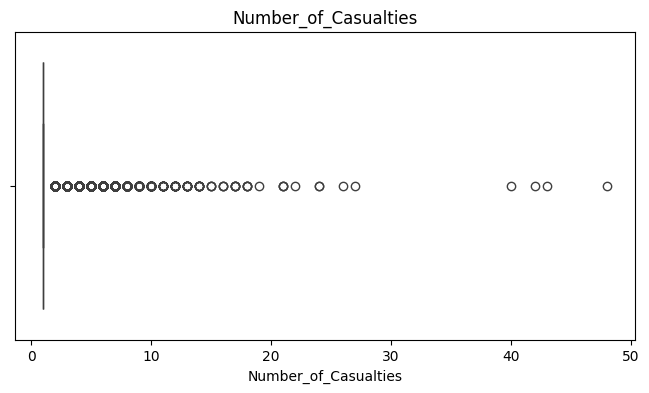

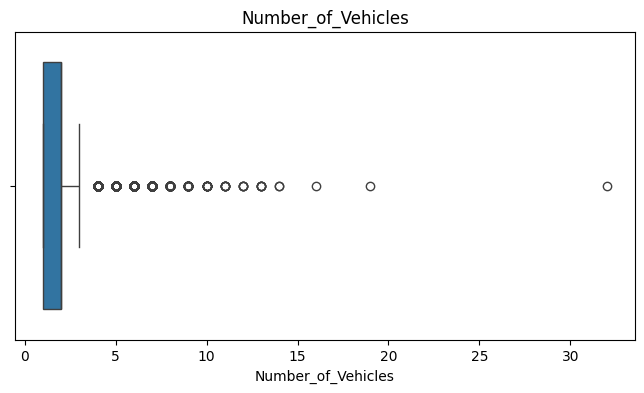

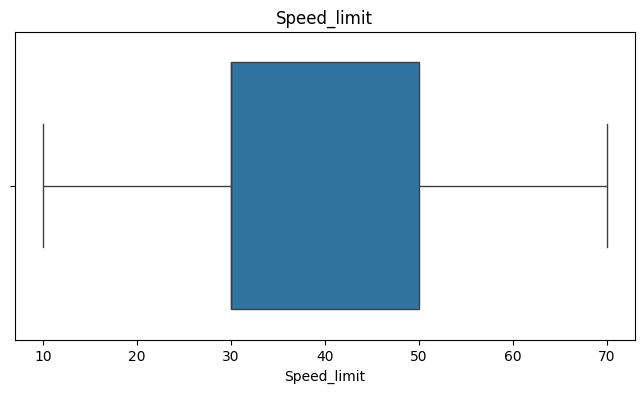

In [20]:
num_cols = [
    'Number_of_Casualties',
    'Number_of_Vehicles',
    'Speed_limit'
]

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [21]:
df['Casualty_Per_Vehicle'] = (df['Number_of_Casualties'] / df['Number_of_Vehicles'])

In [22]:
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,...,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Year,Month,Day,Hour,Casualty_Per_Vehicle
0,200901BS70001,2021-01-01,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,-0.201349,...,30,1900-01-01 15:11:00,Urban,Fine no high winds,Car,2021.0,1.0,1.0,15,0.5
1,200901BS70002,2021-05-01,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,-0.199248,...,30,1900-01-01 10:59:00,Urban,Fine no high winds,Taxi/Private hire car,2021.0,5.0,1.0,10,5.5
2,200901BS70003,2021-04-01,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,-0.179599,...,30,1900-01-01 14:19:00,Urban,Fine no high winds,Taxi/Private hire car,2021.0,4.0,1.0,14,0.5
3,200901BS70004,2021-05-01,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,-0.203110,...,30,1900-01-01 08:10:00,Urban,Other,Motorcycle over 500cc,2021.0,5.0,1.0,8,0.5
4,200901BS70005,2021-06-01,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,-0.173445,...,30,1900-01-01 17:25:00,Urban,Fine no high winds,Car,2021.0,6.0,1.0,17,0.5


In [35]:
df.to_csv('Cleaned_Road_Accident_Data.csv', index=False)

# Data Visualization

### Accident Severity Distribution

<Axes: xlabel='count', ylabel='Accident_Severity'>

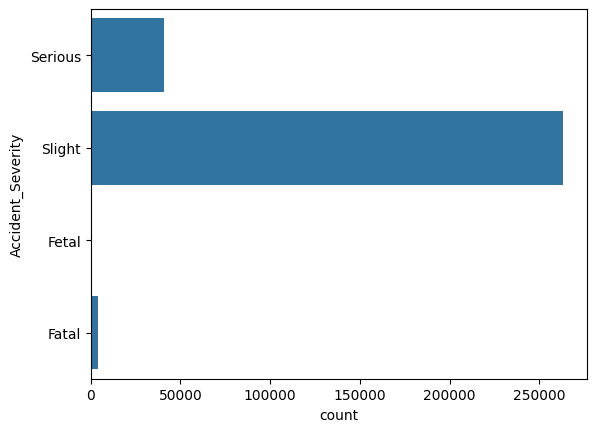

In [23]:
sns.countplot(y='Accident_Severity', data=df)

### Accidents by Day

<Axes: xlabel='Day_of_Week', ylabel='count'>

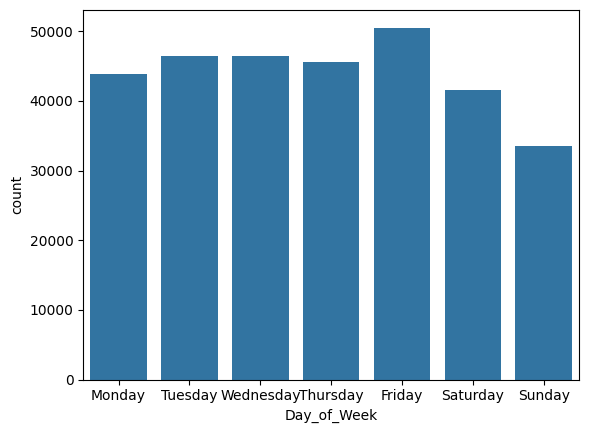

In [24]:
sns.countplot(x='Day_of_Week', data=df, order=[
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
])

### Accidents by Hour

<Axes: xlabel='Hour', ylabel='Count'>

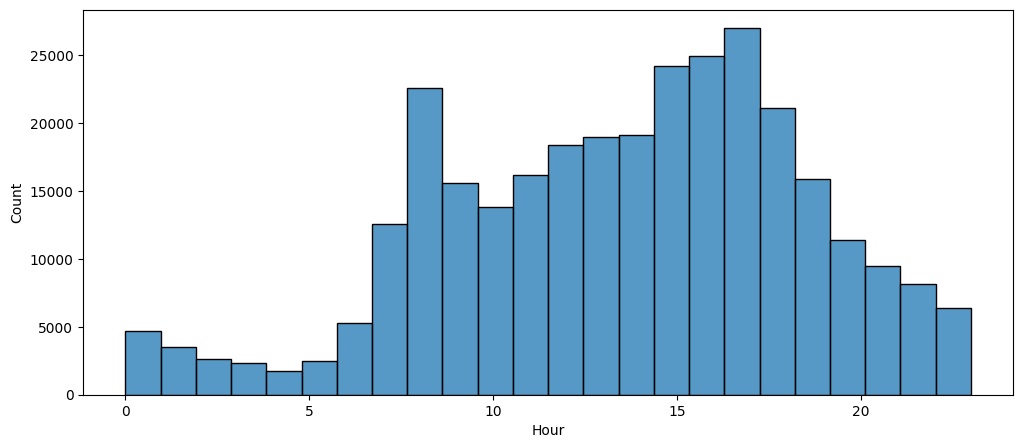

In [26]:
plt.figure(figsize=(12,5))

sns.histplot(x='Hour', data=df, bins=24)

### Weather Impact

<Axes: xlabel='count', ylabel='Weather_Conditions'>

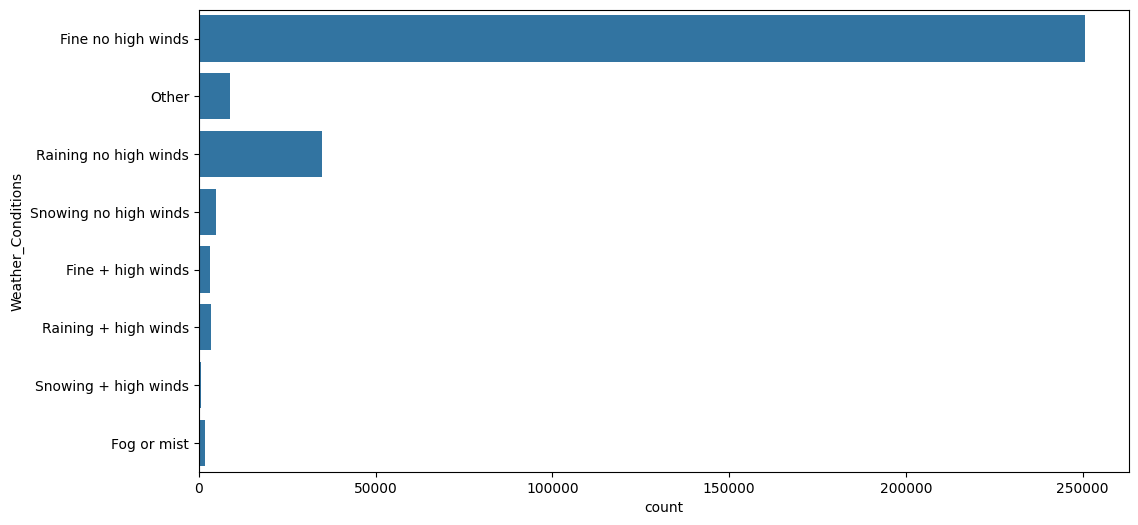

In [27]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Weather_Conditions',
    data=df,
)

### Road Surface Analysis

<Axes: xlabel='count', ylabel='Road_Surface_Conditions'>

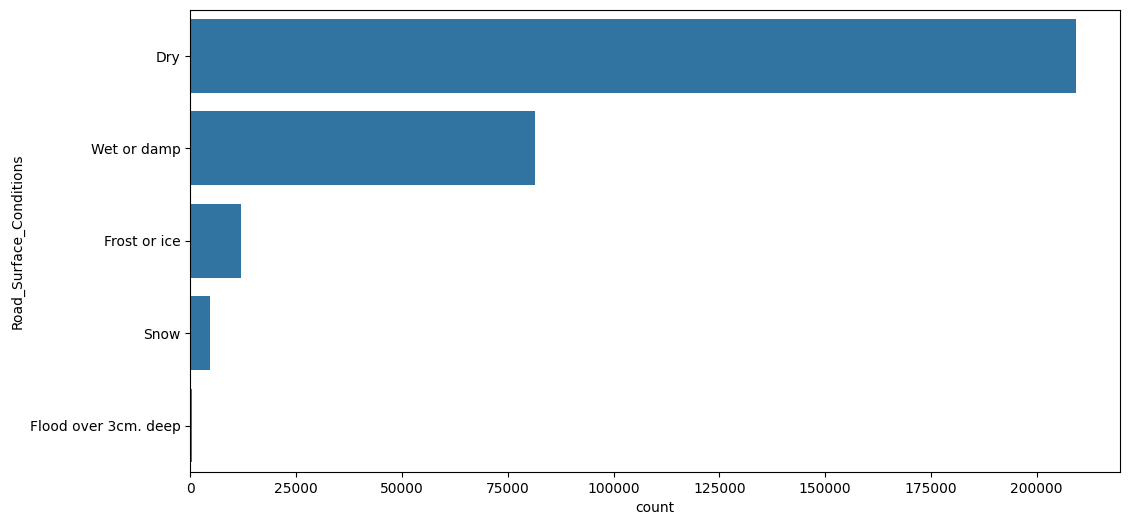

In [28]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Road_Surface_Conditions',
    data=df,
)

### Urban Vs Rural

<Axes: xlabel='Urban_or_Rural_Area', ylabel='count'>

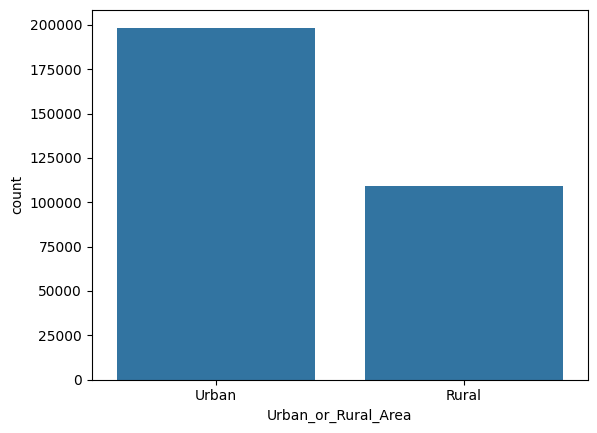

In [29]:
sns.countplot(x='Urban_or_Rural_Area', data=df)

### Vehicle Type Analysis

<Axes: xlabel='count', ylabel='Vehicle_Type'>

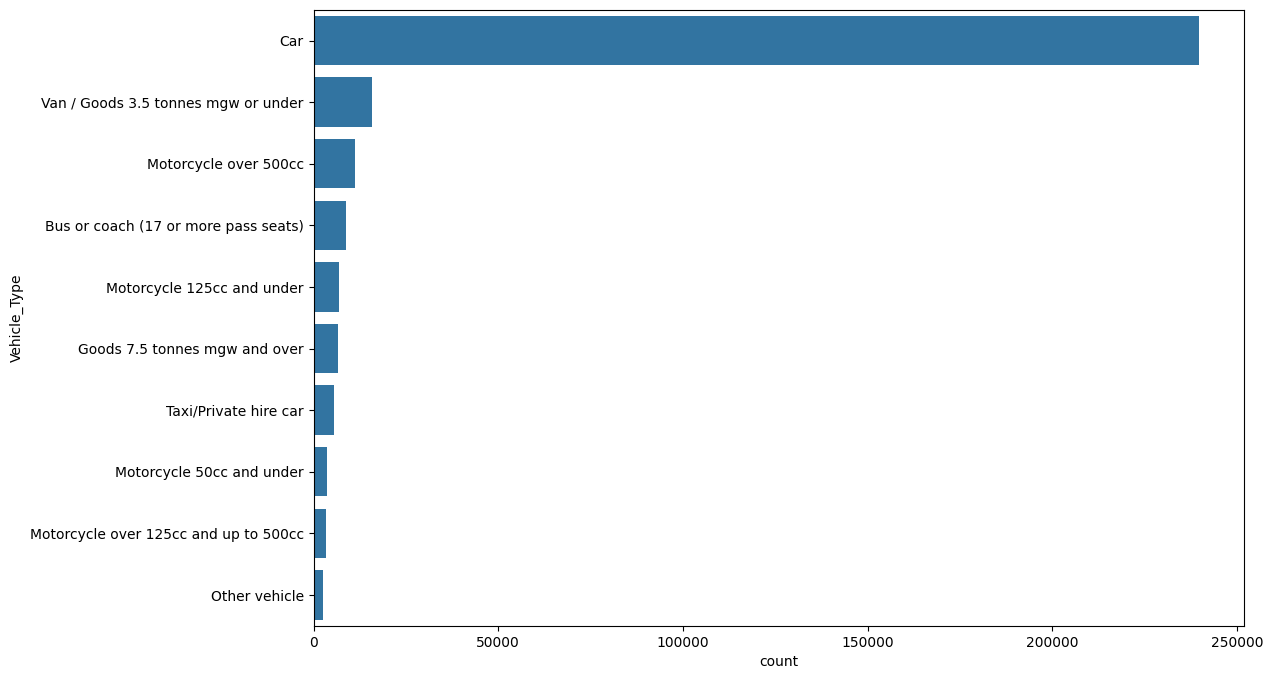

In [30]:
plt.figure(figsize=(12,8))

sns.countplot(
    y='Vehicle_Type',
    data=df,
    order=df['Vehicle_Type'].value_counts().index[:10]
)

### Speed Limit Vs Casualties

<Axes: xlabel='Speed_limit', ylabel='Number_of_Casualties'>

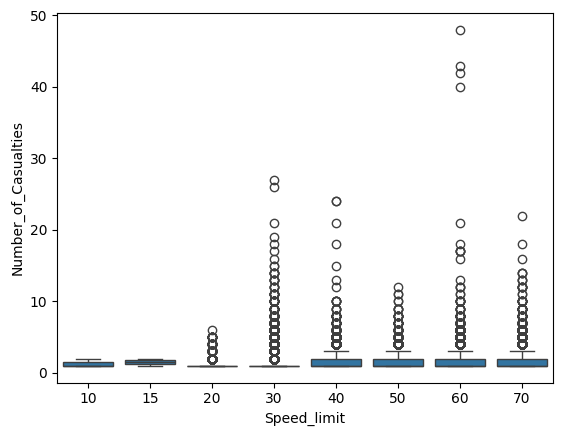

In [31]:
sns.boxplot(x='Speed_limit', y='Number_of_Casualties', data=df)

### Monthly Accident Trend

<Axes: xlabel='Month', ylabel='count'>

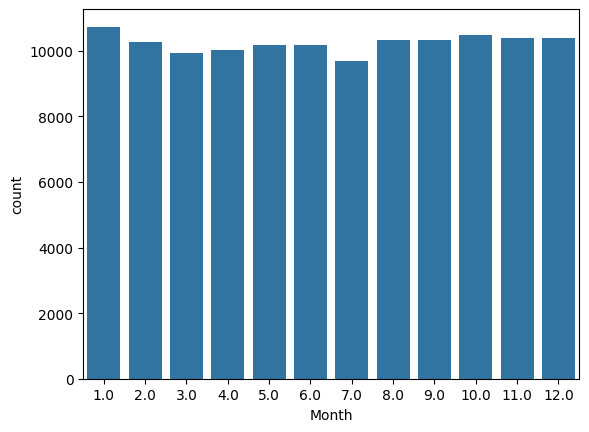

In [32]:
sns.countplot(x='Month', data=df)

### Correlation Heatmap

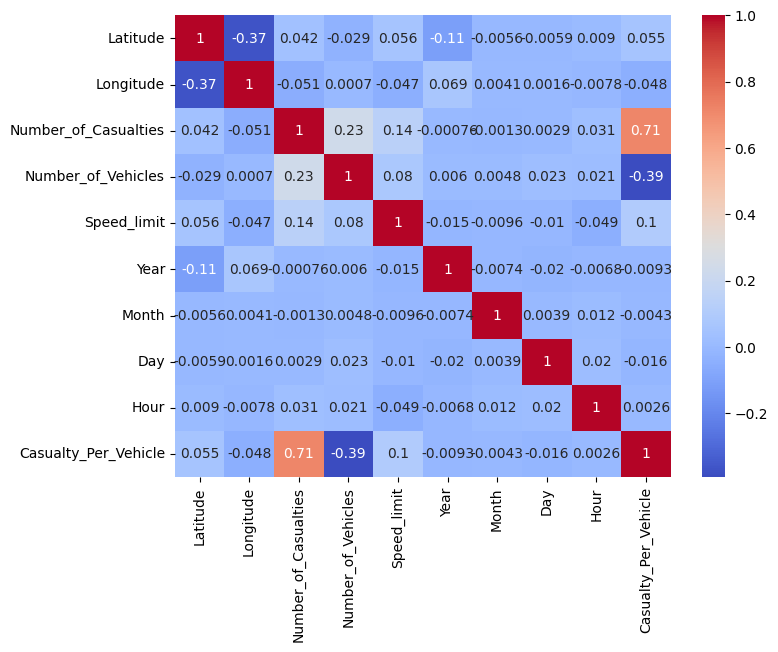

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()